In [ ]:
import pandas as pd
df=pd.read_csv("/content/cleaned_data.csv")
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes,PaymentMethod
0,0,0-1 yr,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,True,False,True,False,False,PaymentMethod_Electronic check
1,0,2-4 yr,56.95,1889.50,True,False,False,True,False,False,...,False,False,True,False,False,False,False,True,False,PaymentMethod_Mailed check
2,0,0-1 yr,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,True,False,False,True,True,PaymentMethod_Mailed check
3,0,2-4 yr,42.30,1840.75,True,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,PaymentMethod_Credit card (automatic)
4,0,0-1 yr,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,True,False,True,False,True,PaymentMethod_Electronic check


In [ ]:
df.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes', 'PaymentMethod'],
      dtype='object')

In [ ]:
df['charge_group']=pd.cut(df['MonthlyCharges'],bins=[0,35,70,100,150],labels=['low','medium','high','very high'])

In [ ]:
df[['MonthlyCharges', 'ChargeGroup']].head()

,MonthlyCharges,ChargeGroup
0,29.85,Low
1,56.95,Medium
2,53.85,Medium
3,42.30,Medium
4,70.70,High


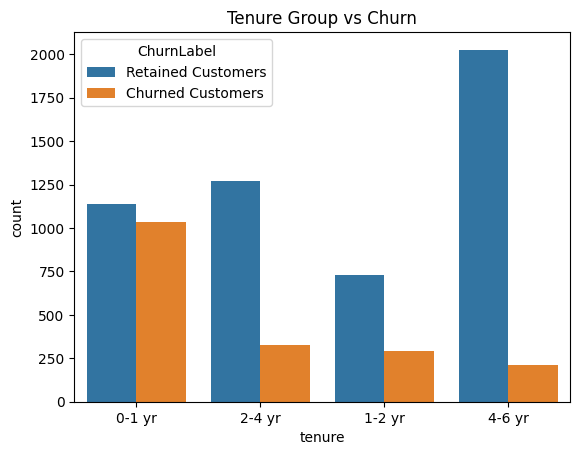

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='tenure', hue='ChurnLabel', data=df)
plt.title("Tenure Group vs Churn")
plt.show()

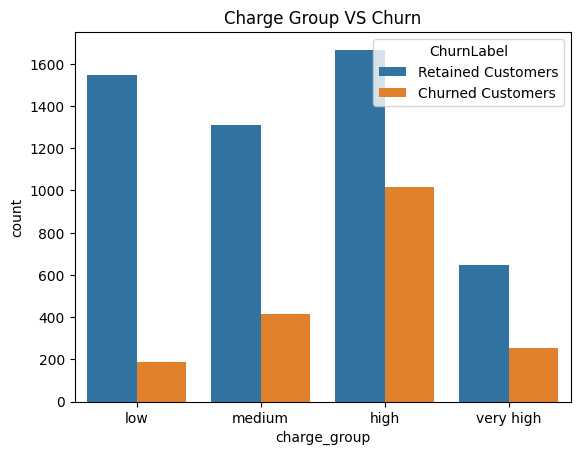

In [ ]:
sns.countplot(x='charge_group',hue='ChurnLabel',data=df)
plt.title("Charge Group VS Churn")
plt.show()

In [ ]:
df['Churn_Yes'].unique()

array([False,  True])

In [ ]:
high_value_customers = df[(df['ChargeGroup'].isin(['High', 'Very High'])) &(df['Churn_Yes'] == True)]

In [ ]:
high_value_customers.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes,PaymentMethod,ChargeGroup,charge_group,ChurnLabel
4,0,0-1 yr,70.70,151.65,False,False,False,True,False,False,...,False,True,False,True,False,True,PaymentMethod_Electronic check,High,high,Churned Customers
5,0,0-1 yr,99.65,820.50,False,False,False,True,False,True,...,False,True,False,True,False,True,PaymentMethod_Electronic check,High,high,Churned Customers
8,0,2-4 yr,104.80,3046.05,False,True,False,True,False,True,...,False,True,False,True,False,True,PaymentMethod_Electronic check,Very High,very high,Churned Customers
13,0,4-6 yr,103.70,5036.30,True,False,False,True,False,True,...,False,True,False,False,False,True,PaymentMethod_Credit card (automatic),Very High,very high,Churned Customers
26,0,2-4 yr,99.35,4749.15,True,True,True,True,False,True,...,False,True,False,True,False,True,PaymentMethod_Electronic check,High,high,Churned Customers


In [ ]:
df.to_csv("Clean_Data_Churn_Prediction.csv",index=False)